# Setup

In [2]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
sorted([f for f in sorted(os.listdir('data')) if f.startswith('df_rgc')])

['df_rgc_2026-01-08-16h.pickle',
 'df_rgc_2026-01-09-11h.pickle',
 'df_rgc_2026-01-09-14h.pickle',
 'df_rgc_2026-01-12-15h.pickle',
 'df_rgc_2026-01-12-16h.pickle',
 'df_rgc_2026-01-12-17h.pickle',
 'df_rgc_2026-01-15-16h.pickle',
 'df_rgc_2026-01-16-09h.pickle',
 'df_rgc_2026-01-16-13h.pickle',
 'df_rgc_2026-01-16-17h.pickle',
 'df_rgc_2026-01-23-12h.pickle',
 'df_rgc_2026-01-23-13h.pickle',
 'df_rgc_2026-01-23-14h.pickle',
 'df_rgc_2026-02-05-16h.pickle',
 'df_rgc_2026-02-06-10h.pickle',
 'df_rgc_2026-02-06-11h.pickle',
 'df_rgc_2026-02-21-10h.pickle',
 'df_rgc_2026-02-25-09h.pickle',
 'df_rgc_2026-02-25-10h.pickle',
 'df_rgc_feat_names_2026-01-16-09h.csv',
 'df_rgc_feat_names_2026-01-16-13h.csv',
 'df_rgc_feat_names_2026-01-16-17h.csv',
 'df_rgc_feat_names_2026-01-23-12h.csv',
 'df_rgc_feat_names_2026-01-23-13h.csv',
 'df_rgc_feat_names_2026-01-23-14h.csv',
 'df_rgc_feat_names_2026-02-05-16h.csv',
 'df_rgc_feat_names_2026-02-06-10h.csv',
 'df_rgc_feat_names_2026-02-06-11h.csv',
 'df

In [4]:
#version = '2026-02-25-10h'  # Resource paper
version = '2026-02-25-10h'

all_feat_names = pd.read_csv(f"data/df_rgc_feat_names_{version}.csv").columns[1:]
df = pd.read_pickle(f"data/df_rgc_{version}.pickle")
print(df.shape)
print(df.columns)
for f in all_feat_names:
    assert f in df.columns

df.head()

(2480, 173)
Index(['ew', 'ccls_id', 'post_has_cal', 'post_has_axon', 'polar_dens_id',
       'row', 'link', 'nuc', 'status', 'status_alt',
       ...
       'norm-log_tortuosity_median', 'norm-branch_angle_mean',
       'norm-branch_angle_std', 'norm-path_angle_mean', 'norm-path_angle_std',
       'norm-log_radius_mean', 'norm-log_radius_std', 'tsne_d0', 'tsne_d1',
       'leiden_cluster'],
      dtype='object', length=173)


,ew,ccls_id,post_has_cal,post_has_axon,polar_dens_id,row,link,nuc,status,status_alt,...,norm-log_tortuosity_median,norm-branch_angle_mean,norm-branch_angle_std,norm-path_angle_mean,norm-path_angle_std,norm-log_radius_mean,norm-log_radius_std,tsne_d0,tsne_d1,leiden_cluster
cell,,,,,,,,,,,,,,,,,,,,,
720575940537162675,2,5,1,1,1,E2443,https://spelunker.cave-explorer.org/#!middleau...,720575940557784449,Complete (cut off),None,...,0.586863,1.436251,-1.131998,0.820221,0.086144,-0.590815,-0.044251,-29.947247,-55.127720,34
720575940537274291,2,5,1,1,1,H258,https://spelunker.cave-explorer.org/#!middleau...,720575940557420044,Complete,None,...,-1.880682,-1.967932,3.016201,-0.357269,2.393318,2.505953,1.958817,52.893150,-65.645370,24
720575940537313971,2,5,1,1,1,H1081,https://spelunker.cave-explorer.org/#!middleau...,720575940555058738,Complete,None,...,-0.779414,-0.386843,0.572619,-1.488369,-0.718009,0.215942,0.632087,2.030082,-0.618252,10
720575940537341619,2,5,1,1,1,H1217,https://spelunker.cave-explorer.org/#!middleau...,720575940563935725,Complete,None,...,1.124681,1.366297,-0.796876,0.532632,-0.149579,-0.608144,-0.914692,-69.049858,21.740580,5
720575940537343155,2,5,1,1,1,H1167,https://spelunker.cave-explorer.org/#!middleau...,720575940564762137,Complete,None,...,0.645208,-1.478450,-0.094217,-1.659505,-1.814256,0.556565,0.621826,68.627724,23.535620,1


# Labels

### Select subset for plotting

In [5]:
df_subset = pd.read_csv('RGC types for Figure.csv')

In [6]:
subset_list_short = df_subset['Show'][df_subset['Show'].notnull()].values

In [7]:
len(subset_list_short)

34

### Collect labels

In [8]:
human_labels = np.array(df.celltype_merged.values)
human_labels_short = np.array(df.celltype_short.values)

df['in subset'] = [(l in subset_list_short) for l in human_labels_short]

df['is_labelled'] = df.is_labelled & ~df.celltype_merged.isin(['ON DS transient']) & df['in subset']
is_labelled = df['is_labelled']

human_labels[~is_labelled] = 'none'
unique_human_labels = np.sort(np.unique(human_labels[is_labelled]))
unique_human_labels_short = np.sort(np.unique(human_labels_short[is_labelled]))

In [9]:
print(len(unique_human_labels), len(unique_human_labels_short))
unique_human_labels

26 26


array(['F-mini-OFF', 'F-mini-ON', 'HD1', 'HD2', 'Local edge detector',
       'M1', 'M2', 'M6', 'OFF medium sustained', 'OFF sustained alpha',
       'OFF transient alpha', 'OFF transient medium RF',
       'OFF transient small RF', 'OFF vertical OS - asymmetric',
       'ON DS sustained', 'ON OS large RF', 'ON OS small RF', 'ON alpha',
       'ON small OFF large', 'ON transient medium RF',
       'ON transient small RF', 'ON vertical OS large RF',
       'ON vertical OS small RF', 'ON-OFF DS', 'PixON', 'UHD'],
      dtype=object)

In [10]:
unique_human_labels_short

array(['FmOff', 'FmOn', 'HD1', 'HD2', 'LED', 'M1', 'M2', 'M5', 'M6',
       'OODS', 'On-s-Off-l', 'OnOS-l', 'OnOS-s', 'UHD', 'sOff-a',
       'sOff-m', 'sOn-a', 'sOnDS', 'tOff-a', 'tOff-m', 'tOff-s', 'tOn-m',
       'tOn-s', 'vOffOS', 'vOnOS-l', 'vOnOS-s'], dtype=object)

# Figures

In [10]:
from eyewire2_morphological_clustering.utils.style import set_rc_params

set_rc_params()

In [11]:
fig_dir = f'figures/rgc_{version}'
os.makedirs(fig_dir, exist_ok=True)

# Dendrograms

In [12]:
all_feats_norm = df[['norm-' + f for f in all_feat_names]].values

In [13]:
from eyewire2_morphological_clustering.utils.dendrogram import ClusterDendrogram

cd = ClusterDendrogram(
    data=all_feats_norm[is_labelled],
    cluster_labels=human_labels_short[is_labelled],
    feature_names=all_feat_names,
)
avg_features = cd.compute_cluster_averages(log_transform=False)
filtered_features, selected_features = cd.filter_features(verbose=False)
dist_matrix = cd.compute_distance_matrix(metric='euclidean')
Z = cd.hierarchical_cluster(method='average')

In [14]:
import warnings
from eyewire2_morphological_clustering.utils.dendrogram import PairwiseDiscriminability

pair_ds = PairwiseDiscriminability(regularization='ledoit_wolf')
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    dend = pair_ds.fit(all_feats_norm[is_labelled], human_labels_short[is_labelled])

Computing pairwise discriminability for 26 classes...
Total pairs: 325


In [15]:
from scipy.cluster.hierarchy import dendrogram, linkage

dendro = dendrogram(
    cd.Z,
    labels=cd.clusters,
    leaf_font_size=8,
    color_threshold=0,
    above_threshold_color='gray',
    no_plot=True,
)

In [16]:
leaf_order = cd.clusters[dendro['leaves']]
leaf_order

array(['M2', 'M1', 'vOffOS', 'FmOff', 'tOn-m', 'tOn-s', 'FmOn', 'UHD',
       'HD1', 'HD2', 'LED', 'M5', 'M6', 'OnOS-l', 'OnOS-s', 'On-s-Off-l',
       'sOff-a', 'sOff-m', 'tOff-a', 'tOff-m', 'tOff-s', 'sOn-a',
       'vOnOS-l', 'vOnOS-s', 'OODS', 'sOnDS'], dtype=object)

In [17]:
len(unique_human_labels)

26

In [18]:
len(leaf_order)

26

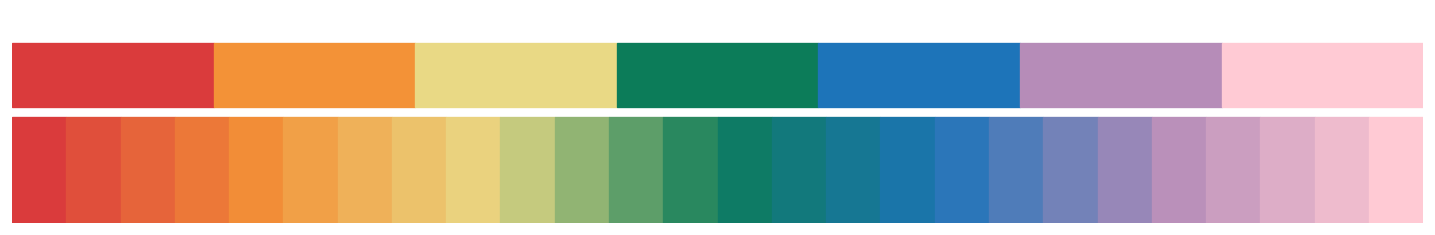

In [19]:
from eyewire2_morphological_clustering.utils import colors

interpolated_colors = colors.interpolate_colors(n=len(unique_human_labels))
ordered_colors = colors.reorder_colors_for_distinction(interpolated_colors, n_neighbors=4)

label2color = {leaf_name: ordered_colors[i] for i, leaf_name in enumerate(leaf_order)}

## Plot stats

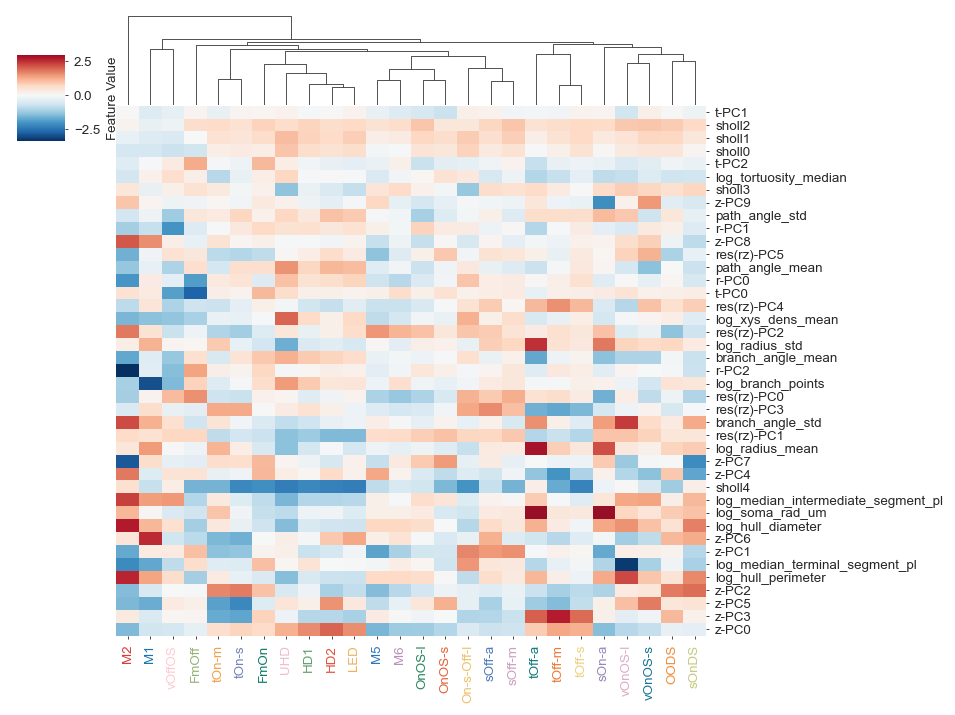

In [20]:
fig = cd.plot_heatmap_with_dendrogram(top_n_features=50, figsize=(8, 6)) #cd

ax = fig.ax_heatmap
ax.set_xlabel(None)
ax.set_ylabel(None)
ax.tick_params("x", rotation=90)
xlabels = ax.get_xmajorticklabels()
xlabelnames = []
for label in xlabels:
    label.set_color(label2color[label.get_text()])

fig.savefig(f'{fig_dir}/rgc-dendrogram_features.svg')
fig.savefig(f'{fig_dir}/rgc-dendrogram_features.png', dpi=600)
plt.show()

## Plot dendrogram

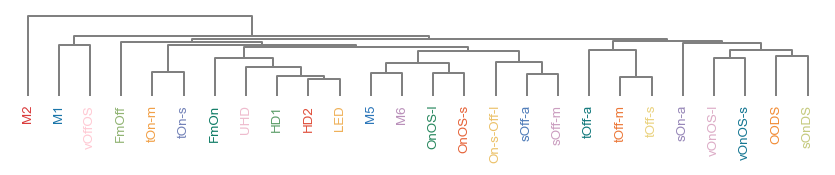

In [21]:
fig, ax = plt.subplots(figsize=(7, 1.5))
sns.despine(left=True, bottom=True, right=True, top=True)

# Plot dendrogram
dendro = dendrogram(
    cd.Z,
    labels=cd.clusters,
    ax=ax,
    leaf_font_size=8,
    color_threshold=0,
    above_threshold_color='gray',
    no_plot=False,
)

ax.tick_params("x", rotation=90)
xlabels = ax.get_xmajorticklabels()
xlabelnames = []
for label in xlabels:
    label.set_color(label2color[label.get_text()])

assert len(np.unique(xlabelnames)) == len(xlabelnames)

ax.set_yticks([])
plt.tight_layout()

fig.savefig(f'{fig_dir}/rgc-dendrogram.svg')
fig.savefig(f'{fig_dir}/rgc-dendrogram.png', dpi=600)
plt.show()

# TSNE

/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/embedding.py:229: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


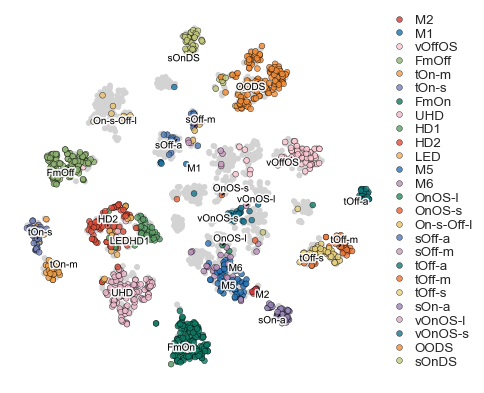

In [22]:
from eyewire2_morphological_clustering.utils.embedding import plot_embedding_v2

plot_embedding_v2(
    df=df,
    label2color=label2color,
    fig_path_prefix=f"{fig_dir}/rgc-tsne",
    celltype_col="celltype_short",
    plot_order=leaf_order,
    is_labelled_col="is_labelled",
    dot_size=12,
    edgecolor="k",
    rasterized=False,
    legend_markerscale=None,
)

## Feature maps

In [23]:
example_feature_names = [
    'perc_z_005',
    'perc_z_095',

    'log_hull_diameter',
    'log_branch_points',
    
    'log_soma_rad_um',
    'log_radius_mean',
        
    #'log_xys_dens_mean',
    #'log_median_intermediate_segment_pl',
    #'log_median_terminal_segment_pl',
    #'perc_z_025',
    #'perc_z_050',
]

example_features = df.loc[:, example_feature_names].values

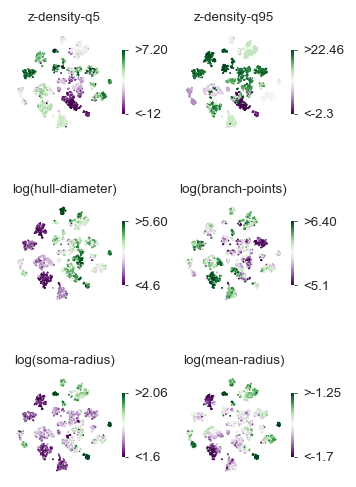

In [24]:
from eyewire2_morphological_clustering.utils.embedding import save_and_plot_feats

fig, axs = save_and_plot_feats(
    all_emb=df.loc[:, ['tsne_d0', 'tsne_d1']].values,
    all_feats=example_features,
    all_feat_names=example_feature_names, 
    ncols=2,
    fig_dir=fig_dir,
    file_prefix="rgc-tnse-features",
    clip=False,
    stride=1, 
    s=1,
    figsize_per_cell=(1.5, 1.5)
)

# Morph examples

## Get one per type

In [25]:
size_order = df[df.is_labelled].groupby('celltype_short').aggregate({'hull_diameter': 'mean'}).sort_values('hull_diameter').index.values

In [26]:
all_types_rows = []

for celltype_short in size_order:
    rows = df[(df.celltype_short == celltype_short) & df.is_labelled]
    
    if len(rows) == 0:
        rows = None
        print(celltype)

    if rows is None:
        row = None
    else:
        x = rows['tsne_d0']
        y = rows['tsne_d1']
        
        emb_ct = np.stack([x, y]).T
        
        ct_mean = np.mean(emb_ct, axis=0)
        ct_dists = np.sum((emb_ct - ct_mean) ** 2, axis=1) ** 0.5
        row = rows.iloc[np.argmin(ct_dists)]
        
    all_types_rows.append(row)
    
all_types_rows = pd.DataFrame(all_types_rows)
all_types_rows.head(2)

,ew,ccls_id,post_has_cal,post_has_axon,polar_dens_id,row,link,nuc,status,status_alt,...,norm-branch_angle_mean,norm-branch_angle_std,norm-path_angle_mean,norm-path_angle_std,norm-log_radius_mean,norm-log_radius_std,tsne_d0,tsne_d1,leiden_cluster,in subset
720575940565684702,2,5,1,1,1,D232,https://spelunker.cave-explorer.org/#!middleau...,720575940562377319,Complete,None,...,1.124686,-0.969674,1.004611,0.250136,-1.534109,-1.957314,-38.109100,-48.787518,4,True
720575940571326484,2,5,1,1,1,D246,https://spelunker.cave-explorer.org/#!middleau...,720575940560471823,Complete,None,...,0.544085,-1.075331,0.436935,0.006559,-0.192312,0.130142,-70.848862,19.785847,5,True


In [27]:
for i, name in all_types_rows['celltype'].items():
    print(i, name)

720575940565684702 UHD
720575940571326484 F-mini-OFF
720575940567134539 ON small OFF large
720575940560812962 Local edge detector
720575940580727221 F-mini-ON
720575940584832054 HD2
720575940567987466 HD1
720575940575166201 ON transient small RF
720575940573267005 OFF transient small RF
720575940556475444 ON OS small RF - orientation unknown
720575940553644312 OFF transient medium RF
720575940553729816 ON transient medium RF
720575940557316450 OFF medium sustained
720575940580411288 ON-OFF DS - direction unknown
720575940578607562 OFF vertical OS - asymmetric
720575940568897823 ON OS large RF - orientation unknown
720575940569273438 OFF sustained alpha
720575940565657858 M6
720575940558574893 PixON
720575940554583314 ON vertical OS small RF
720575940569093970 OFF transient alpha
720575940562833781 M1
720575940559376739 ON alpha
720575940569959961 ON vertical OS large RF
720575940556814278 ON DS sustained - direction unknown
720575940550970944 M2


0
Index([720575940565684702, 720575940571326484, 720575940567134539,
       720575940560812962, 720575940580727221, 720575940584832054,
       720575940567987466, 720575940575166201, 720575940573267005],
      dtype='int64')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


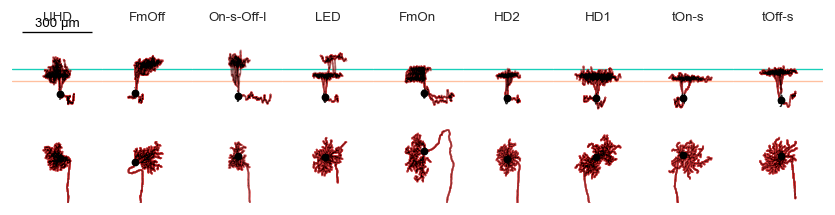

1
Index([720575940556475444, 720575940553644312, 720575940553729816,
       720575940557316450, 720575940580411288, 720575940578607562,
       720575940568897823, 720575940569273438, 720575940565657858],
      dtype='int64')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


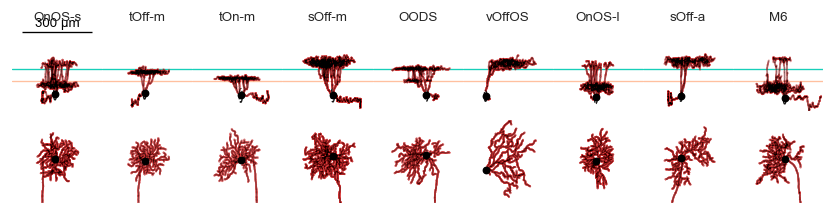

2
Index([720575940558574893, 720575940554583314, 720575940569093970,
       720575940562833781, 720575940559376739, 720575940569959961,
       720575940556814278, 720575940550970944],
      dtype='int64')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


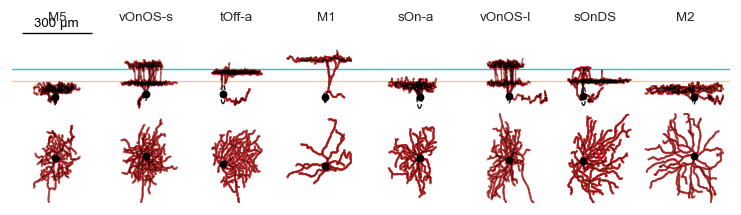

In [28]:
from eyewire2_morphological_clustering.utils.plot_cells import plot_rows

nrows = 3

rad = (all_types_rows.hull_diameter.max() / 2) * 1.1

for i in range(nrows):
    print(i)
    rows = np.array_split(all_types_rows, nrows)[i]
    fig, axs = plt.subplots(
        2, len(rows), figsize=(7 * len(rows) / 9, 2.2),
        sharex='all', sharey='row', squeeze=False, height_ratios=(1.7, 4),
        subplot_kw=dict(xlabel=None, ylabel=None, xticks=[], yticks=[]), layout='tight')
    for ax in axs.flat:
        ax.axis('off')
    print(rows.index.astype(int))
    fig, fig2 = plot_rows(
        rows=rows, rad=rad,
        size=300, fig=fig, axs=axs,
        color=colors.cellclass2color['RGC'],
        #color_list=[label2color[ct] for ct in rows.celltype_short.values],
        show_on_tsne=False, sb_fontsize=8)

    for j, ax in enumerate(axs[0, :]):
        ax.set_title(rows.iloc[j].celltype_short, fontsize=8)

    fig.savefig(f'{fig_dir}/celltype-example_set{i}.svg', dpi=600, bbox_inches='tight')
    fig.savefig(f'{fig_dir}/celltype-example_set{i}.png', dpi=600, bbox_inches='tight')
    
    plt.show()

## Types

In [29]:
# celltype = 'ON alpha'

# rows = df[(df.celltype == celltype) & (df.celltype_pred == celltype)].iloc[[0, 4, 3]]
# print(rows.index.astype(int))
# plot_rows(rows=rows, rad=170, color=celltype2color[label2long[celltype]], size=100, savename=label2short[celltype])

In [30]:
# celltype = 'UHD'

# rows = df[(df.celltype == celltype) & (df.celltype_pred == celltype)].iloc[[0, 10, 20]]
# print(rows.index.astype(int))
# plot_rows(rows=rows, rad=100, color=celltype2color[label2long[celltype]], size=100, savename=celltype)

In [31]:
# celltype = 'ON transient small RF'

# rows = df[(df.celltype == celltype)].iloc[[1, 4, 3]]
# print(rows.index.astype(int))
# plot_rows(rows=rows, rad=150, color=celltype2color[label2long[celltype]], size=100, savename=label2short[celltype])

In [32]:
# celltype = 'M1'

# rows = df[(df.celltype == celltype)].iloc[[1, 2, 3]]
# print(rows.index.astype(int))
# plot_rows(rows=rows, rad=200, color=celltype2color[label2long[celltype]], size=100, savename=label2short[celltype])

In [33]:
# celltype = 'M2'

# rows = df[(df.celltype == celltype)].iloc[[0, 5, 6]]
# print(rows.index.astype(int))
# plot_rows(rows=rows, rad=300, color=celltype2color[label2long[celltype]], size=100, savename=label2short[celltype])

# Coverage

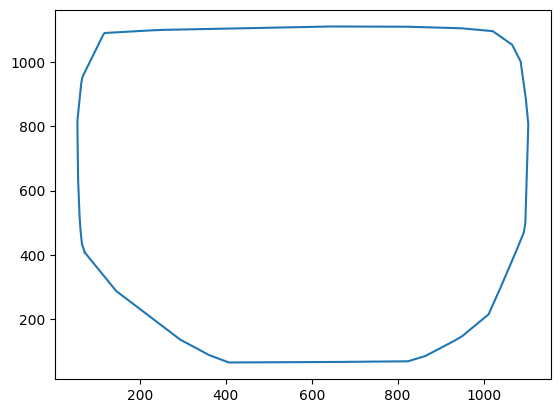

In [13]:
from scipy.spatial import ConvexHull

pts = np.vstack(df.hull_points)[:, :2]
hull = ConvexHull(pts)

# Get hull boundary points in order, closed
hull_pts = pts[np.append(hull.vertices, hull.vertices[0])]
plt.plot(*hull_pts.T)
plt.show()

In [35]:
# # TODO: reorder by size?
# # TODO: cell figure plot
# # TODO: try other big cells, like M1, M2, EW28?
# celltypes = ["sOn-a", "tOff-a", "tOff-s", "FmOn", "FmOff", "M1", "UHD", "OODS"]

# for name, extent in {'wide': [100, 1100, 150, 1150], 'zoom': [200, 400, 600, 800], 'zoom2': [200, 300, 600, 700]}.items():

#     fig, axs = plt.subplots(ncols=len(celltypes), nrows=1, figsize=(7, 1.2), sharex='all', sharey='all', squeeze=False)    
#     sns.despine(top=False, right=False)
#     plot_mosaics(celltypes, fig, axs, max_val=10, extent=extent, plot_outlines='zoom' in name.lower())
#     fig.savefig(f'{fig_dir}/rgc-mosaic-{celltypes}_set{i}_{extent}.svg', dpi=600, bbox_inches='tight')
#     fig.savefig(f'{fig_dir}/rgc-mosaic-{celltypes}_set{i}_{extent}.png', dpi=600, bbox_inches='tight')
#     plt.show()

In [14]:
from eyewire2_morphological_clustering.utils.mosaics import plot_multiple_mosaics

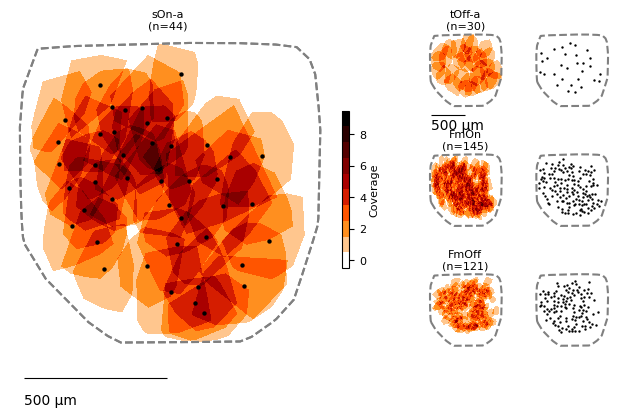

In [18]:
extent = [20, 1120, 50, 1150]
max_val = 9

fig, naxs = plt.subplot_mosaic(
    """
    A.Bb
    A.Cc
    A.Dd
    """,
    figsize=(7, 4.1),
    sharex=True,
    sharey=True,
    width_ratios=(4, 0.3, 1, 1),
    #subplot_kw=dict(xticks=[], yticks=[]),
)

coverage_axs = np.array([naxs['A'], naxs['B'], naxs['C'], naxs['D']])
center_axs = np.array([naxs['A'], naxs['b'], naxs['c'], naxs['d']])
sb_axs = np.array([naxs['A'], naxs['B']])

celltypes = ["sOn-a", "tOff-a", "FmOn", "FmOff"]
sns.despine(top=True, right=True, bottom=True, left=True)

df_filtered = df[df["is_labelled"]].copy()
med = df_filtered.groupby("celltype_short")["ood_shape"].transform("median") # compute median ood_shape per cell type
df_filtered = df_filtered[df_filtered["ood_shape"] < 3 * med]  # remove cells with ood_shape >= 3x the group median

ims, c_maxs = plot_multiple_mosaics(
    df=df_filtered,
    celltype_col='celltype_short',
    celltypes=celltypes,
    fig=fig,
    coverage_axs=coverage_axs,
    resolutions=[3000, 1000, 1000, 1000],
    center_axs=center_axs,
    title_axs=coverage_axs,
    center_x_col="soma_x_um",
    center_y_col="soma_y_um",
    marker_sizes=[10, 3, 3, 3],
    max_val=max_val,
    extent=extent,
    plot_outlines=False,
    outline_hull=hull_pts,
    cb=False,
    sb_axs=sb_axs,
    sb_size=500,
)

plt.tight_layout(w_pad=0)

#naxs['A'].plot(430, 450, 'Xb', ms=30, alpha=0.5)

# Custom color bar
for i, celltype in enumerate(celltypes):
    ax = coverage_axs[i]
    im = ims[i]
    c_max = c_maxs[i]
    
    if i > 0:
        if c_max == c_maxs[i-1]:
            continue
    
    pos = ax.get_position()
    
    cax = fig.add_axes([
        pos.x1 + 0.025, # left
        pos.y0 + 0.25 * pos.height,   # bottom (adjust spacing)
        0.01,    
        pos.height * 0.5,
    ])
    
    cbar = fig.colorbar(im, cax=cax, orientation='vertical')
    cbar.set_label('Coverage', fontsize=8, labelpad=2)
    cbar.set_ticks(np.arange(0, c_max + 1, int(np.ceil(c_max/5))))
    cbar.ax.tick_params(labelsize=8)
    cbar.outline.set_visible(True)

#fig.savefig(f'{fig_dir}/rgc-mosaic-{celltypes}_{extent}.svg', dpi=600, bbox_inches='tight')
#fig.savefig(f'{fig_dir}/rgc-mosaic-{celltypes}_{extent}.png', dpi=600, bbox_inches='tight')

plt.show()

# Copy all figures

In [64]:
import shutil

shutil.copytree(fig_dir, f"/gpfs01/euler/data/Resources/Eyewire2/{fig_dir}", dirs_exist_ok=True)

'/gpfs01/euler/data/Resources/Eyewire2/figures/rgc_2026-02-25-10h'

In [63]:
fig_dir

'figures/rgc_2026-02-25-10h'

# Credits

In [24]:
morph_examples = [
    "720575940565684702",
    "720575940571326484",
    "720575940567134539",
    "720575940560812962",
    "720575940580727221",
    "720575940584832054",
    "720575940567987466",
    "720575940575166201",
    "720575940573267005",
    "720575940556475444",
    "720575940553644312",
    "720575940553729816",
    "720575940557316450",
    "720575940580411288",
    "720575940578607562",
    "720575940568897823",
    "720575940569273438",
    "720575940565657858",
    "720575940558574893",
    "720575940554583314",
    "720575940569093970",
    "720575940562833781",
    "720575940559376739",
    "720575940569959961",
    "720575940556814278",
    "720575940550970944",
]

In [26]:
df_plot

,ew,ccls_id,post_has_cal,post_has_axon,polar_dens_id,row,link,nuc,status,status_alt,...,norm-branch_angle_mean,norm-branch_angle_std,norm-path_angle_mean,norm-path_angle_std,norm-log_radius_mean,norm-log_radius_std,tsne_d0,tsne_d1,leiden_cluster,in subset
cell,,,,,,,,,,,,,,,,,,,,,
720575940537274291,2,5,1,1,1,H258,https://spelunker.cave-explorer.org/#!middleau...,720575940557420044,Complete,None,...,-1.967932,3.016201,-0.357269,2.393318,2.505953,1.958817,52.893150,-65.645370,24,True
720575940537341619,2,5,1,1,1,H1217,https://spelunker.cave-explorer.org/#!middleau...,720575940563935725,Complete,None,...,1.366297,-0.796876,0.532632,-0.149579,-0.608144,-0.914692,-69.049858,21.740580,5,True
720575940537434291,2,5,1,1,1,H1651,https://spelunker.cave-explorer.org/#!middleau...,720575940567710921,Complete,None,...,0.738450,-0.513520,-0.113068,0.301188,-0.189429,0.069761,-65.755989,22.998226,5,True
720575940537466547,2,5,1,1,1,H1798,https://spelunker.cave-explorer.org/#!middleau...,720575940562141808,Complete,None,...,0.912008,-0.759014,0.737612,0.209523,-0.099853,-0.131225,-77.285698,11.849860,15,True
720575940537569971,2,5,1,1,1,H1838,https://spelunker.cave-explorer.org/#!middleau...,720575940545782106,Complete,None,...,1.518223,-0.671194,0.911082,0.128248,-1.541608,-2.100387,0.931503,-68.582062,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
720575940585259030,2,5,1,1,1,E815,https://spelunker.cave-explorer.org/#!middleau...,720575940536049425,Complete,None,...,0.939218,-0.922200,-0.071555,-0.115279,-0.475203,-0.602459,-63.821854,22.900761,5,True
720575940585508150,2,5,1,1,1,H16,https://spelunker.cave-explorer.org/#!middleau...,720575940562784063,Complete,None,...,0.774252,-0.470315,0.894994,-0.044990,-0.689856,-0.100349,-5.420444,-71.110855,2,True
720575940587311613,2,5,1,1,1,E220,https://spelunker.cave-explorer.org/#!middleau...,720575940542998624,Complete,None,...,-0.324853,0.515889,0.895244,1.288272,0.196300,0.052171,-1.978069,-86.704437,25,True


In [29]:
df_plot = df_filtered[df_filtered['celltype_short'].isin(celltypes) | df_filtered.index.isin(morph_examples)].copy()
print(df_plot.shape)
df_plot['has_been_used'] = True
df_plot[['row', 'nuc', 'has_been_used']].to_csv('data/rgc_figure_credits.csv')

(362, 174)
